<a href="https://colab.research.google.com/github/ianelgar40/IansMIS433/blob/main/Copy_of_assignment_IMDB_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [1]:
import pandas as pd
import numpy as np

In [23]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN


In [3]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [5]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb.Released_Year.value_counts()

,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [26]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
imdb.loc[imdb.Released_Year != imdb.Released_Year.str(4)]

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [43]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
imdb.loc[966, 'Released_Year']=1995
imdb.loc[966, 'Certificate']= 'PG'
imdb.loc[966]

,966
Poster_Link,https://m.media-amazon.com/images/M/MV5BNjEzYj...
Series_Title,Apollo 13
Released_Year,1995
Certificate,PG
Runtime,140 min
Genre,"Adventure, Drama, History"
IMDB_Rating,7.6
Overview,NASA must devise a strategy to return Apollo 1...
Meta_score,77.0
Director,Ron Howard


In [45]:
# Change the data type of "Released_Year" to int
imdb.Released_Year = imdb.Released_Year.astype(int)
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   int64  
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 125.1+ KB


In [71]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
imdb.loc[(imdb.Released_Year >= 2010) & (imdb.IMDB_Rating >= 8.5), ['Series_Title', 'Released_Year', 'Certificate', 'Gross']].sort_values(by='Gross', ascending=False)

,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [ ]:
# Does the sorting result looks right to you? What's the problem?


In [72]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe
imdb.Gross.astype(str)
imdb.Gross = imdb.Gross.str.replace(',', '')
imdb.Gross = imdb.Gross.astype(float)
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   int64  
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
dtypes: float64(3), int64(2), object(11)
memory usage: 125.1+ KB


In [73]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
imdb.loc[(imdb.Released_Year >=2010) & (imdb.IMDB_Rating >=8.5), ['Series_Title', 'Released_Year', 'Certificate', 'Gross']].sort_values(by='Gross', ascending=False)

,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [74]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe
imdb['Runtime_min']=imdb.Runtime.str.replace(' min', '').astype(int)
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   int64  
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
 16  Runtime_min    1000 non-null   int64  
dtypes: float64(3), int64(3), object(11)
memory usage: 132

In [76]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
imdb['Age_Year']= 2026 - imdb.Released_Year
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142,32
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175,54
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152,18
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202,52
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96,69


In [80]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade']=(imdb.Released_Year) // 10 * 10
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year,Decade
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142,32,1990
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175,54,1970
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152,18,2000
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202,52,1970
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96,69,1950


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Meta_score', ylabel='IMDB_Rating'>

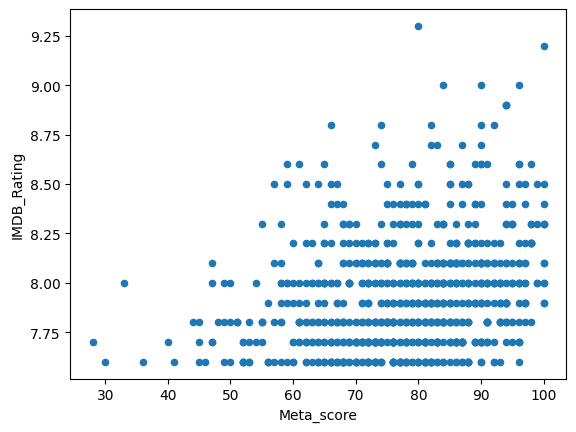

In [84]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.
imdb.plot.scatter(x='Meta_score', y='IMDB_Rating')

<Axes: xlabel='Meta_score', ylabel='IMDB_Rating'>

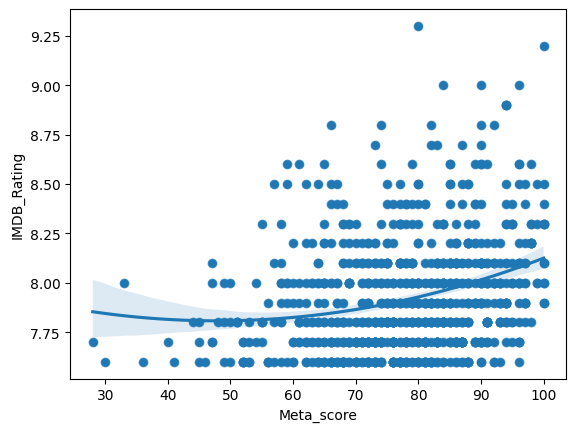

In [100]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.
imdb.plot.scatter(x='Meta_score', y='IMDB_Rating')
sns.regplot(x='Meta_score', y='IMDB_Rating', data=imdb, order=2)

,Series_Title,IMDB_Rating,Meta_score,Decade
423,Il conformista,8.0,100.0,1970
440,Sweet Smell of Success,8.0,100.0,1950
491,Boyhood,7.9,100.0,2010
559,Notorious,7.9,100.0,1940
442,The Night of the Hunter,8.0,99.0,1950
...,...,...,...,...
853,Dirty Harry,7.7,90.0,1970
862,The Birds,7.7,90.0,1960
866,Les yeux sans visage,7.7,90.0,1960
988,Close Encounters of the Third Kind,7.6,90.0,1970


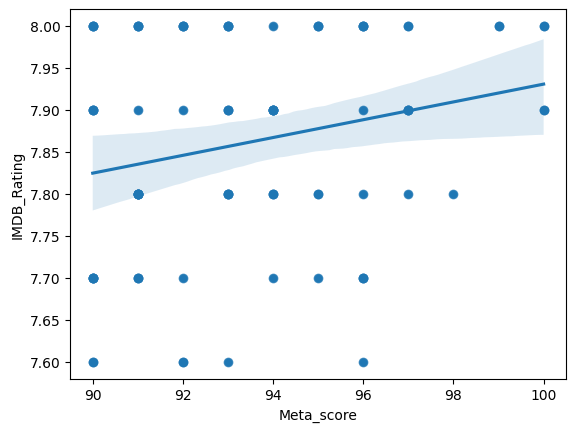

In [119]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.
imdb_bad_meta_good=imdb.loc[(imdb.Meta_score >= 90) & (imdb.IMDB_Rating <= 8), ['Series_Title','IMDB_Rating', 'Meta_score', 'Decade' ]].sort_values(by='Meta_score', ascending=False)
imdb_bad_meta_good.plot.scatter(x='Meta_score', y='IMDB_Rating')
sns.regplot(x='Meta_score', y='IMDB_Rating', data=imdb_bad_meta_good, order=1)
imdb_bad_meta_good


<Axes: xlabel='Meta_score', ylabel='IMDB_Rating'>

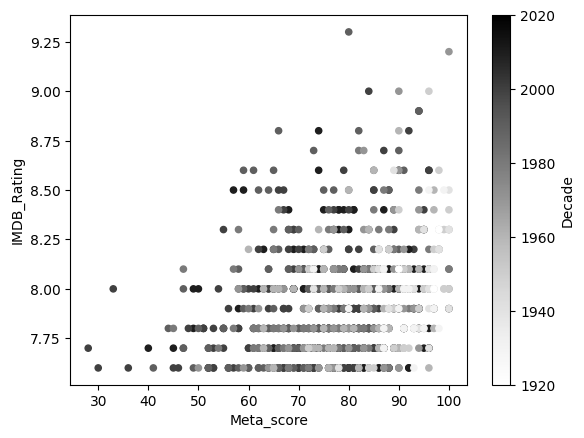

In [114]:
# In the scatterplot, use color to distinguish movies from different decades.
imdb.plot.scatter(x='Meta_score', y='IMDB_Rating', c='Decade')

<Axes: xlabel='Decade'>

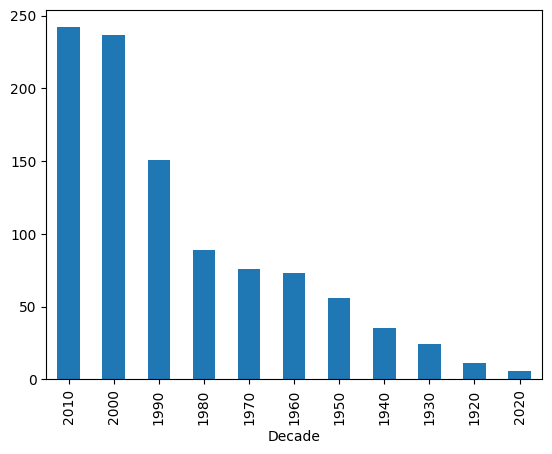

In [120]:
# Create a chart that shows how many movies fall in each decade.
imdb.Decade.value_counts().plot.bar()

<Axes: xlabel='Decade'>

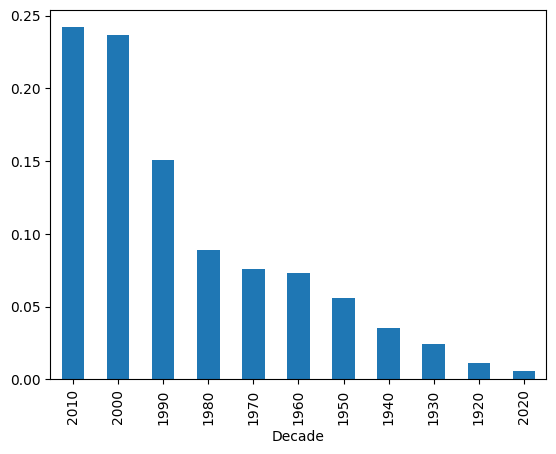

In [121]:
# Create a chart that shows the percentage of movies in each decade.
imdb.Decade.value_counts(normalize=True).plot.bar()

<Axes: xlabel='Director'>

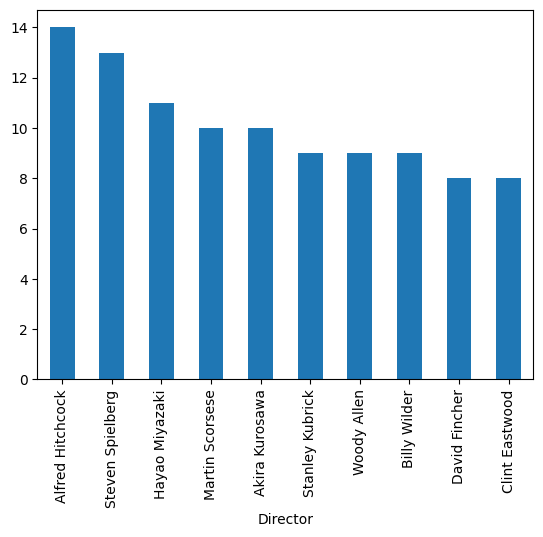

In [127]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.
director_count = imdb.Director.groupby(imdb.Director).count().sort_values(ascending=False).head(10)

director_count.plot.bar()

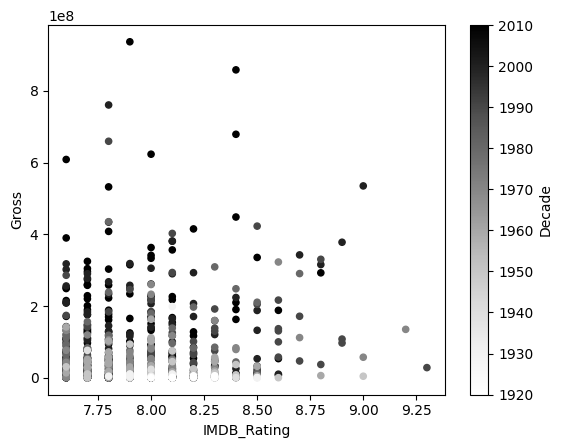

In [132]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.
imdb.plot.scatter(x = 'IMDB_Rating', y = 'Gross', c = 'Decade')

# This scatter plot shows the relationship between these three variables.
# It shows that movies that were made in the early decades generated less Gross revenue than movies that were made recently.
#This scatter plot can also tell us if movies have improved within time.
# Lastly this scatter plot tells us if better movies in terms of ratings, translates into higher gross revenue.


<Axes: ylabel='count'>

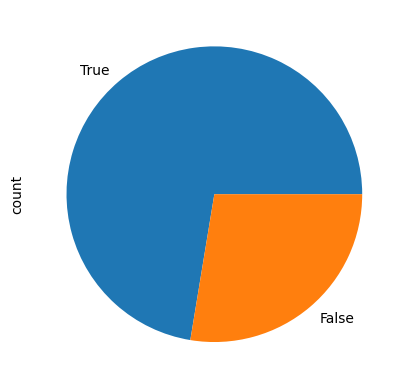

In [135]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.
imdb['Drama']=imdb.Genre.str.contains('Drama')
imdb.Drama.value_counts().plot.pie()

<Axes: xlabel='Decade', ylabel='Gross'>

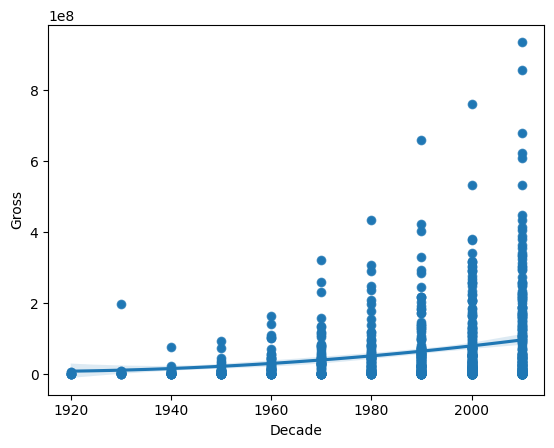

In [140]:
# Create a plot comparing gross revenue across decades.
imdb.plot.scatter(x='Decade', y='Gross')
sns.regplot(x='Decade', y='Gross', data=imdb, order=2)

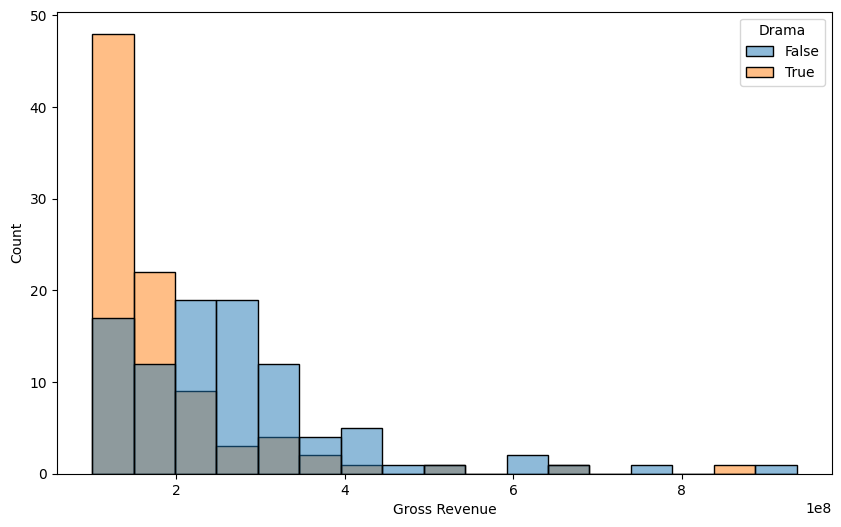

In [152]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.

high_gross_movies = imdb.loc[imdb.Gross >= 100000000]

plt.figure(figsize=(10, 6))
sns.histplot(data=high_gross_movies, x='Gross', hue='Drama')
plt.xlabel('Gross Revenue')
plt.ylabel('Count')
plt.show()

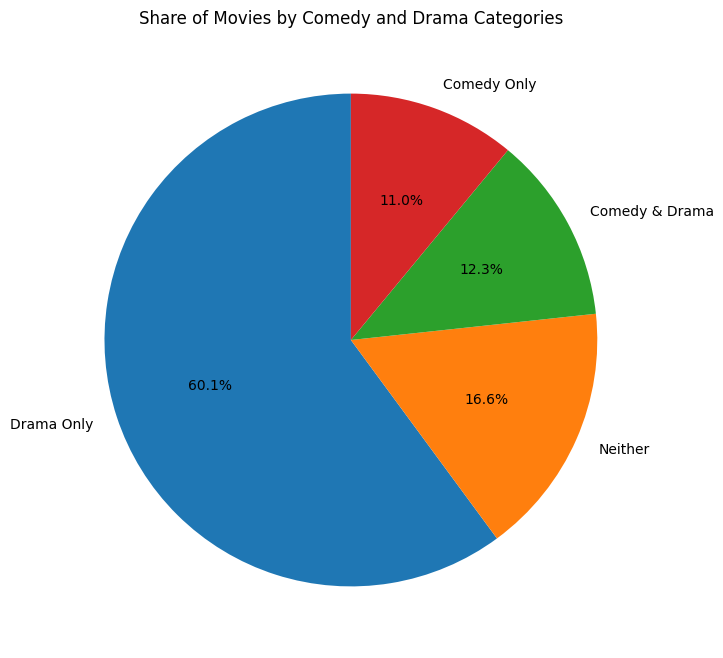

In [157]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: Make a Pie Chart of comedy and / or Drama included
imdb['Comedy']=imdb.Genre.str.contains('Comedy')

conditions = [
    (imdb['Comedy'] == True) & (imdb['Drama'] == True),
    (imdb['Comedy'] == True) & (imdb['Drama'] == False),
    (imdb['Comedy'] == False) & (imdb['Drama'] == True),
    (imdb['Comedy'] == False) & (imdb['Drama'] == False)
]
choices = ['Comedy & Drama', 'Comedy Only', 'Drama Only', 'Neither']
imdb['Category'] = np.select(conditions, choices, default='Unknown')

plt.figure(figsize=(8, 8))
imdb.Category.value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Share of Movies by Comedy and Drama Categories')
plt.ylabel('')
plt.show()


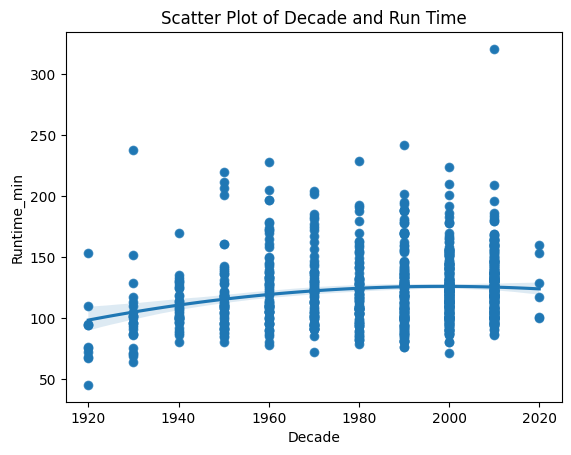

In [159]:
# Question 2: Scatter plot of Decade and run time

imdb.plot.scatter(x='Decade', y='Runtime_min')
sns.regplot(x='Decade', y='Runtime_min', data=imdb, order=2)
plt.title('Scatter Plot of Decade and Run Time')
plt.show()
